# Week 1: Climate Data Basics in Python

This notebook introduces data cleaning and visualization using daily temperature data (CSV format).  
We use `pandas`, `numpy`, `matplotlib`, and `seaborn` to explore and plot climate trends.

## Step 1: Load dataset in pandas

Read the CSV file into a DataFrame.  
This provides a tabular structure for cleaning and analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load daily temperature data
df = pd.read_csv("../data/4221159.csv")

# Inspect first few rows
df.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,PRCP_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,ASN00032040,"TOWNSVILLE AERO, AS",-19.2483,146.7661,4.3,2021-01-01,0.09,",,a",80.0,"H,,S",84.0,",,a",74.0,",,a"
1,ASN00032040,"TOWNSVILLE AERO, AS",-19.2483,146.7661,4.3,2021-01-02,0.00,",,a",80.0,"H,,S",87.0,",,a",76.0,",,a"
2,ASN00032040,"TOWNSVILLE AERO, AS",-19.2483,146.7661,4.3,2021-01-03,NaN,NaN,80.0,"H,,S",85.0,",,a",75.0,",,a"
3,ASN00032040,"TOWNSVILLE AERO, AS",-19.2483,146.7661,4.3,2021-01-04,NaN,NaN,80.0,"H,,S",84.0,",,a",75.0,",,a"
4,ASN00032040,"TOWNSVILLE AERO, AS",-19.2483,146.7661,4.3,2021-01-05,NaN,NaN,78.0,"H,,S",82.0,",,a",76.0,",,a"


## Step 2: Clean dataset

Tasks include:
- Parsing dates into datetime format
- Handling missing values
- Renaming columns for clarity

In [4]:
print(df.columns)

Index(['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE', 'PRCP',
       'PRCP_ATTRIBUTES', 'TAVG', 'TAVG_ATTRIBUTES', 'TMAX', 'TMAX_ATTRIBUTES',
       'TMIN', 'TMIN_ATTRIBUTES'],
      dtype='object')


In [5]:
# Convert date column to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Drop rows with missing temperature values
df = df.dropna(subset=['TMAX', 'TMIN'])

# Rename columns if needed
df = df.rename(columns={'TMAX':'MaxTemp', 'TMIN':'MinTemp'})

## Step 3: Compute basic statistics in numpy/pandas

Examples:
- Daily mean temperature
- Rolling averages
- Annual mean temperature

In [7]:
# Daily mean temperature
df['MeanTemp'] = (df['MaxTemp'] + df['MinTemp']) / 2

# 7-day rolling average
df['RollingMean'] = df['MeanTemp'].rolling(window=7).mean()

# Annual mean temperature
annual_mean = df.groupby(df['DATE'].dt.year)['MeanTemp'].mean()
annual_mean.head()

DATE
2021    77.464187
2022    77.534435
2023    77.024725
2024    77.548209
2025    78.000000
Name: MeanTemp, dtype: float64

## Step 4: Plot daily trend in matplotlib

Line plot of daily mean temperature.  
This shows short-term variability and seasonal cycles.

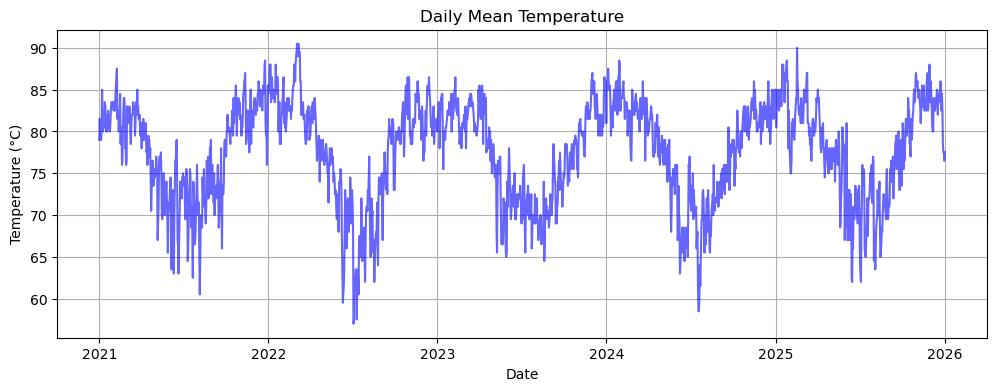

In [10]:
plt.figure(figsize=(12,4))
plt.plot(df['DATE'], df['MeanTemp'], color='blue', alpha=0.6)
plt.title("Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

## Step 5: Plot monthly trend in chronological order

This plot shows the average monthly mean temperature for each month from January 2020 through December 2025.  
- Data is grouped by year and month, then plotted sequentially in time order.  
- Each point represents the mean temperature for that month.  
- The line connects months chronologically, highlighting both seasonal cycles and long-term changes.  
- All months are shown in the same color to emphasize the continuous timeline rather than differences between years.

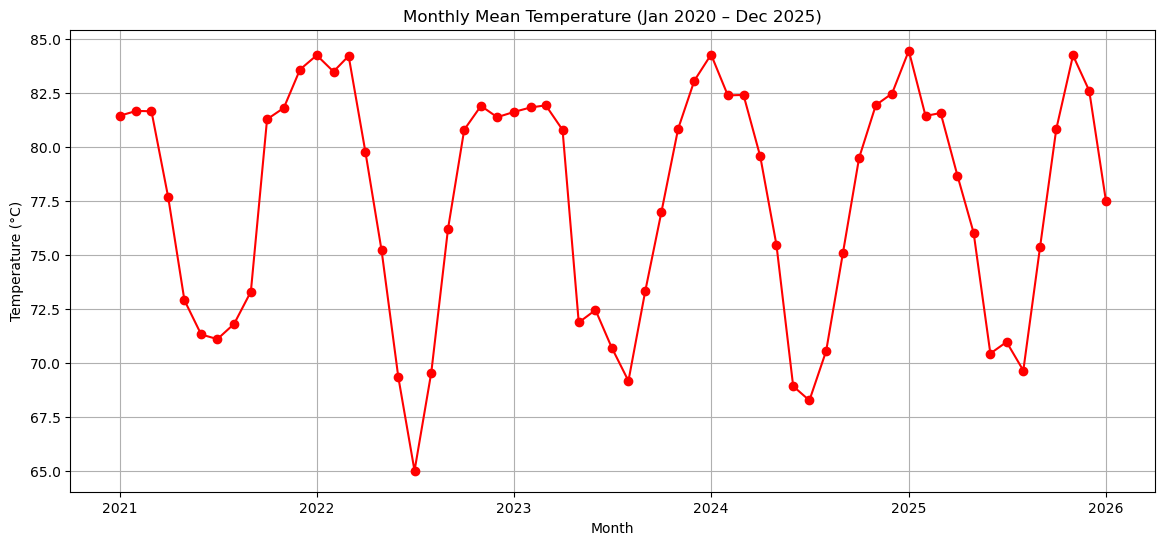

In [16]:
df['DATE'] = pd.to_datetime(df['DATE'])

df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month

monthly_mean_by_year = df.groupby(['Year','Month'])['MeanTemp'].mean().reset_index()

monthly_mean_by_year['YearMonth'] = pd.to_datetime(
    monthly_mean_by_year['Year'].astype(str) + '-' + monthly_mean_by_year['Month'].astype(str) + '-01'
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(monthly_mean_by_year['YearMonth'], monthly_mean_by_year['MeanTemp'], color='red', marker='o')

plt.title("Monthly Mean Temperature (Jan 2020 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

## Step 6: Additional visualizations

Optional plots to explore data distribution:
- Histogram of daily mean temperatures
- Scatter plot of max vs. min temperature

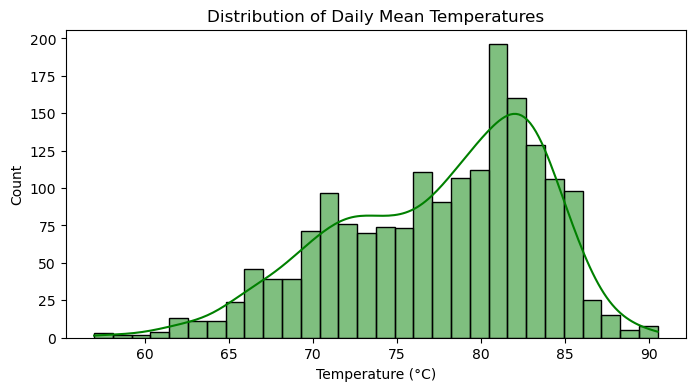

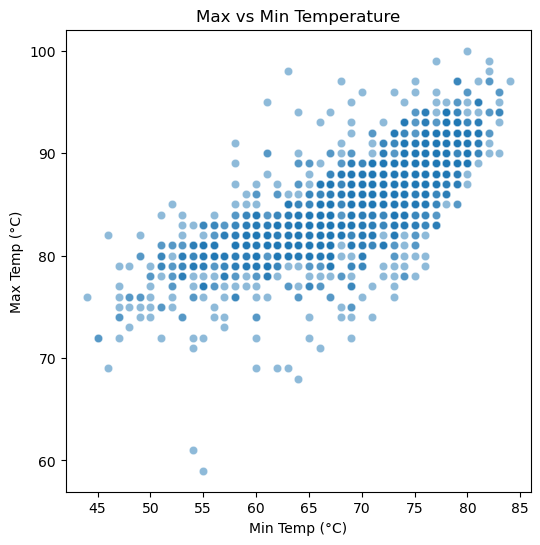

In [18]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['MeanTemp'], bins=30, kde=True, color='green')
plt.title("Distribution of Daily Mean Temperatures")
plt.xlabel("Temperature (°C)")
plt.show()

# Scatter plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=df['MinTemp'], y=df['MaxTemp'], alpha=0.5)
plt.title("Max vs Min Temperature")
plt.xlabel("Min Temp (°C)")
plt.ylabel("Max Temp (°C)")
plt.show()